In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import WeightedRandomSampler

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef,
							accuracy_score, precision_score, recall_score, f1_score)

In [ ]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")


In [ ]:
# To fill nulls for CNN
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 
train


,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,flow_pkts_per_sec,...,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,proto_icmp,proto_udp,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg,Attack_type
0,0.832746,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
1,0.715709,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
2,0.922972,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.250000,0.250000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
3,0.570230,0.000321,0.0,5.330092e-11,0.000282,0.000504,0.000282,0.0,1.000000,1.000000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
4,0.778759,0.093731,0.0,3.198055e-10,0.000282,0.000504,0.000000,0.0,0.160000,0.160000,...,0.015625,0.0,0.015625,0.0,0.0,2.0,2.000000,1.0,1.0,NMAP_OS_DETECTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98488,0.063005,0.000321,0.0,1.599028e-10,0.000282,0.000504,0.000282,0.0,0.307692,0.307692,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98489,0.117723,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98490,0.413428,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98491,0.126421,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping


In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())


Train shape: (98493, 83)
Test shape: (24624, 83)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model


In [ ]:
# Multi class classification
label_encoder = LabelEncoder().fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1).values
X_test = test.drop("Attack_type", axis=1).values


Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


In [ ]:
# put the ports back to one col.
mapping = {
    (1,0): 'icmp',
    (0,1): 'tcp',
    (0,0): 'udp'
}

X_train['port'] = list(zip(X_train.proto_icmp, X_train.proto_tcp))
X_train['port'] = X_train['port'].map(mapping)
X_train = X_train.drop(['proto_icmp','proto_tcp'],axis=1)

smote = SMOTENC(random_state=42,categorical_features=[2,81],sampling_strategy={0: np.rint(6200*1.2,).astype(int),
                                                                            1: np.rint(427*2).astype(int),
                                                                            2: np.rint(75727).astype(int),
                                                                            3: np.rint(3317*1.5).astype(int),
                                                                            4: np.rint(30*3).astype(int),
                                                                            5: np.rint(22*3).astype(int),
                                                                            6: np.rint(1600*1.75).astype(int),
                                                                            7: np.rint(802*2).astype(int),
                                                                            8: np.rint(2072*1.5).astype(int),
                                                                            9: np.rint(1608*1.75).astype(int),
                                                                            10: np.rint(6486*1.2).astype(int),
                                                                            11: np.rint(202*2).astype(int)})
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = pd.get_dummies(X_train_res)
X_train_res = X_train_res.drop(['port_udp'],axis=1)
X_train_res.values.dtype
X_train_res = X_train_res.astype(np.float32)

In [7]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [ ]:
# Convert to 1D CNN format: (batch, channels, sequence_length)
# Add channel dimension for 1D convolution
X_train_cnn = X_train_tensor.unsqueeze(1)  # Shape: (batch, 1, 82)
X_test_cnn = X_test_tensor.unsqueeze(1)    # Shape: (batch, 1, 82)

y = np.array(y_train_res)
class_counts = np.bincount(y)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),replacement=True)


train_dataset = TensorDataset(X_train_cnn, y_train_tensor)
test_dataset = TensorDataset(X_test_cnn, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64)


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)  
        loss = (1 - pt) ** self.gamma * ce


        if self.reduction == 'mean':
            return loss.mean()
        return loss


In [ ]:
class MultiClassAttackCNN(nn.Module):
    def __init__(self, num_classes=12, num_features=83):
        super(MultiClassAttackCNN, self).__init__()
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AvgPool1d(2)
        self.dropout = nn.Dropout(0.3)
        # Self-attention mechanism
        self.attn_embed_dim = 32
        self.num_heads = 8
        self.attn = nn.MultiheadAttention(embed_dim=self.attn_embed_dim, num_heads=self.num_heads, batch_first=True)
        # After pooling: 83 / 2 = 41
        # self.flatten_dim = 32 * 41
        self.fc1 = nn.Linear(32*(num_features//2), 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))

        # Apply self-attention
        B, C, L = x.shape  # Batch, Channels, Length
        x = x.permute(0, 2, 1)  # (B, L, C) for attention
        attn_out, _ = self.attn(x, x, x)
        x = attn_out + x  # Residual connection
        x = x.permute(0, 2, 1).contiguous().view(B, -1)  # Back to (B, C*L)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MultiClassAttackCNN(num_classes=12)
model = model.to(device)
# criterion = nn.CrossEntropyLoss()
criterion=FocalLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


Using device: cuda


In [ ]:
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epcoh")
    for batch, (X_batch, y_batch) in enumerate(train_loader):
        # Move data to GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()
        
        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.3205
Epoch [2/10], Loss: 0.1033
Epoch [3/10], Loss: 0.0781
Epoch [4/10], Loss: 0.0664
Epoch [5/10], Loss: 0.0591
Epoch [6/10], Loss: 0.0541
Epoch [7/10], Loss: 0.0510
Epoch [8/10], Loss: 0.0472
Epoch [9/10], Loss: 0.0453
Epoch [10/10], Loss: 0.0427


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move data to GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)  # multi-class prediction
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Confusion Matrix
print(confusion_matrix(all_labels, all_preds))

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Convert to DataFrame and save as CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_1dcnn_cnn_multi_self_attn.csv", index=True)
print("Success")


[[ 1487     1     0     0    14     4     0     0    21     0    23     0]
 [    0   106     0     0     1     0     0     0     0     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    4     0     0   824     0     0     0     0     1     0     0     0]
 [    0     0     0     0     7     0     0     0     0     0     0     0]
 [    1     0     0     0     0     0     0     0     0     0     5     0]
 [   44     0     0     0     0     0   355     0     0     0     0     1]
 [    0     0     0     0     0     0     0   200     0     0     0     0]
 [    3    24     0     0     2     0     0     0   371     0    23    95]
 [    1     0     0     0     0     1     0     0     0   400     0     0]
 [   36     2     0     0     3     1     0     0     2     0  1575     3]
 [    0     0     0     0     0     0     0     0     2     0     1    48]]
                            precision    recall  f1-score   support

            ARP_poisioning    

In [ ]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds, average='weighted')
recw = recall_score(all_labels, all_preds, average='weighted')
f1w = f1_score(all_labels, all_preds, average='weighted')
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Macro Precision: {precw:.4f}")
print(f"Macro Recall: {recw:.4f}")
print(f"Macro F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.94      0.96      0.95      1550
            DDOS_Slowloris       0.80      0.99      0.88       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      0.99      1.00       829
Metasploit_Brute_Force_SSH       0.26      1.00      0.41         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       1.00      0.89      0.94       400
             NMAP_TCP_scan       1.00      1.00      1.00       200
             NMAP_UDP_SCAN       0.93      0.72      0.81       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.97      0.97      0.97      1622
                Wipro_bulb       0.33      0.94      0.48        51

                  accuracy                           0.99     24624
                 macro

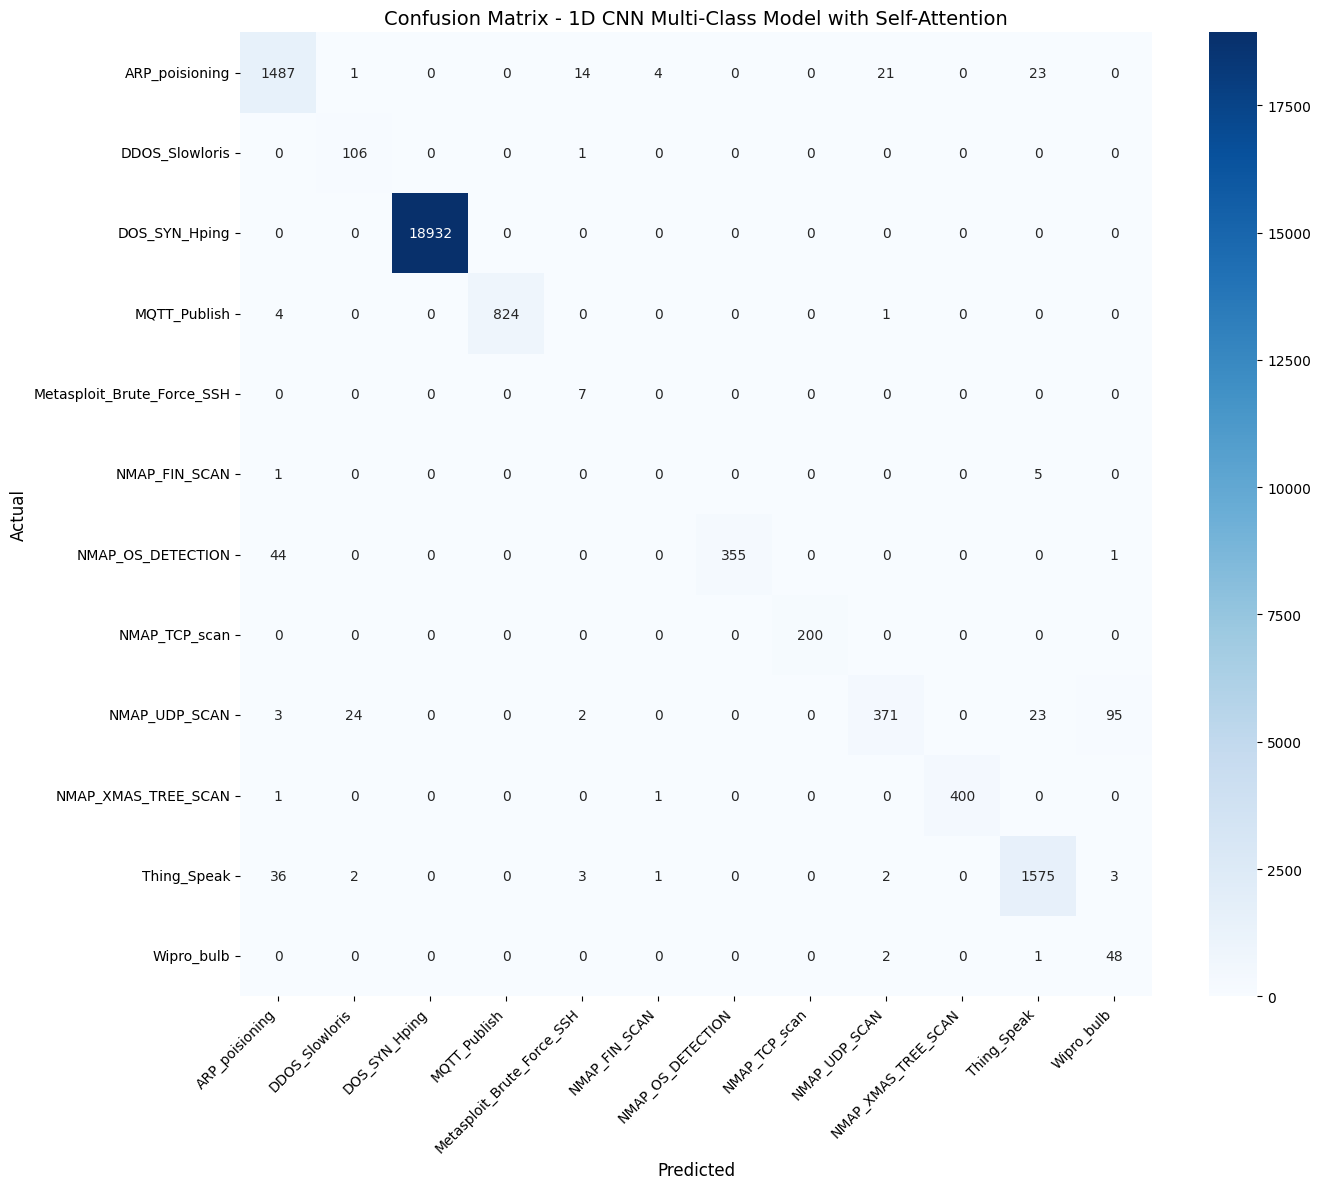

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - 1D CNN Multi-Class Model with Self-Attention", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusionmatrices/1dcnn_attn_multi")
plt.show()


In [ ]:
torch.save(model.state_dict(), "models/1dcnn_multiclass_attn.pth")
print("Model saved to models/1dcnn_multiclass_attn.pth")


Model saved to models/1dcnn_cnn_multiclass_attn.pth
